========== DPCM RESULTS ==========
PCM MSE  : 0.0007703270090782397
DPCM MSE : 0.0004924529984825786


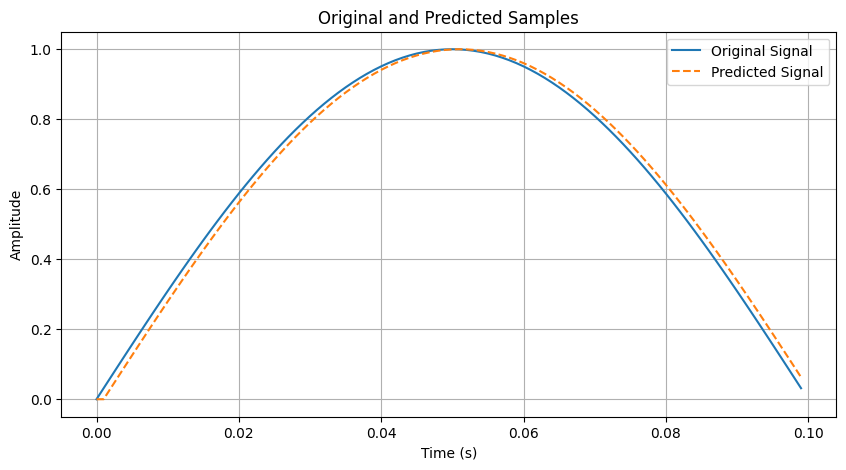

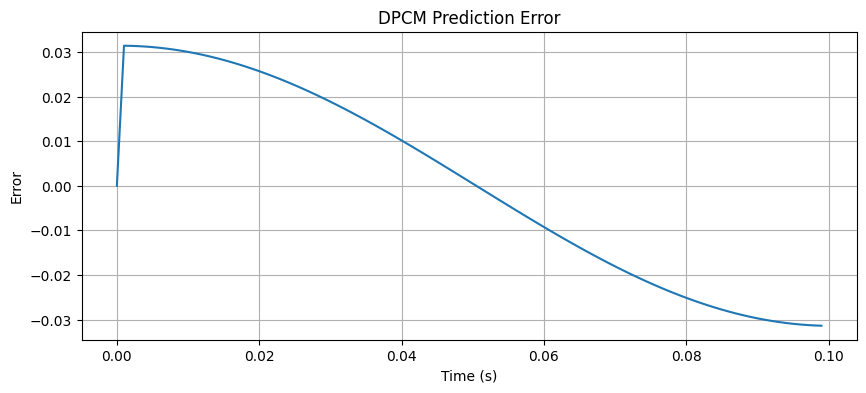

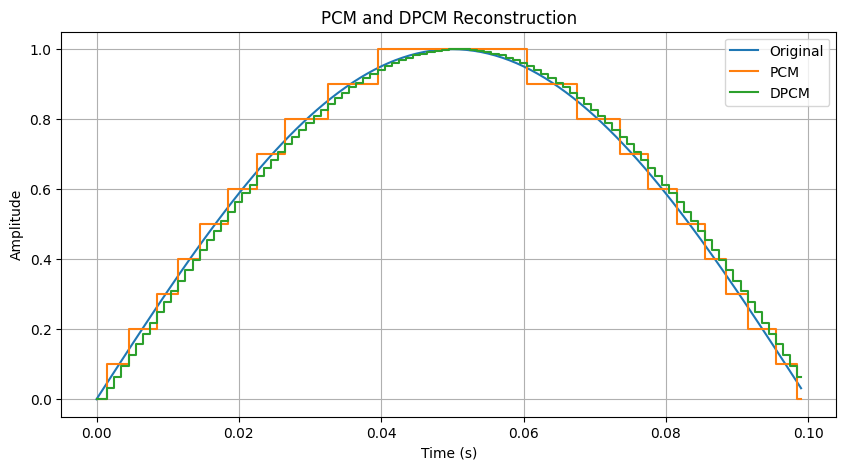

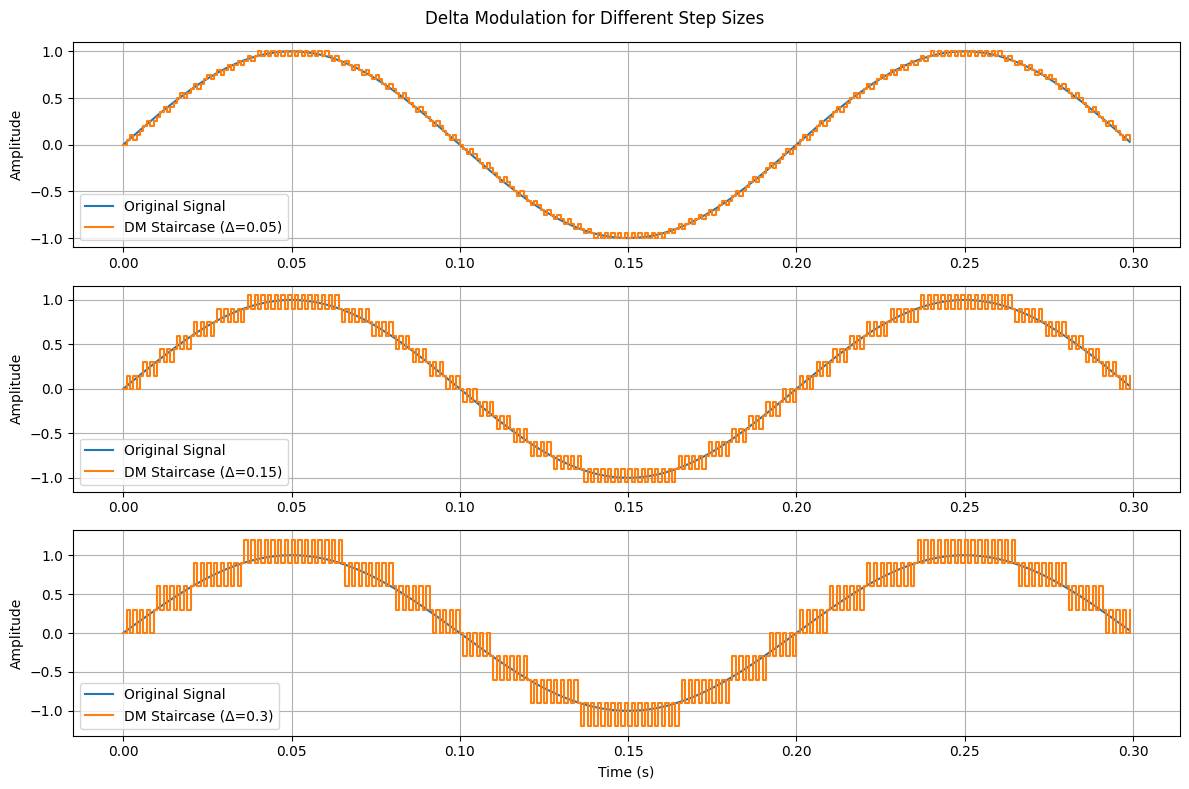


Delta = 0.05

========== DELTA VALIDATION ==========
PASS: Every staircase change is exactly +Δ or -Δ.
Unique staircase changes: [-0.05  0.05]

Delta = 0.15

========== DELTA VALIDATION ==========
PASS: Every staircase change is exactly +Δ or -Δ.
Unique staircase changes: [-0.15  0.15]

Delta = 0.3

========== DELTA VALIDATION ==========
PASS: Every staircase change is exactly +Δ or -Δ.
Unique staircase changes: [-0.3  0.3]


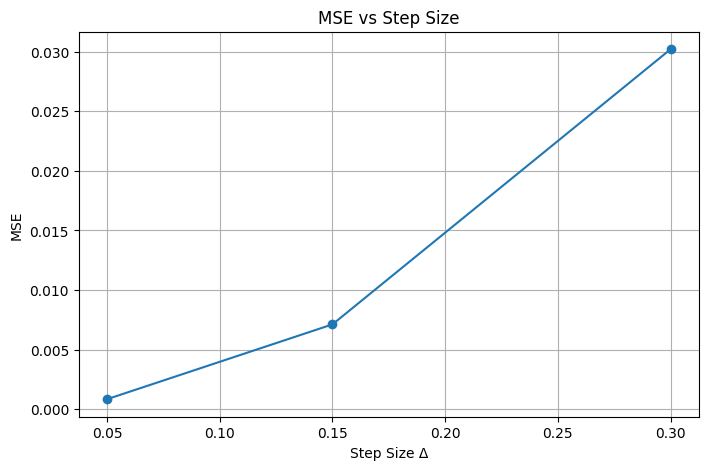

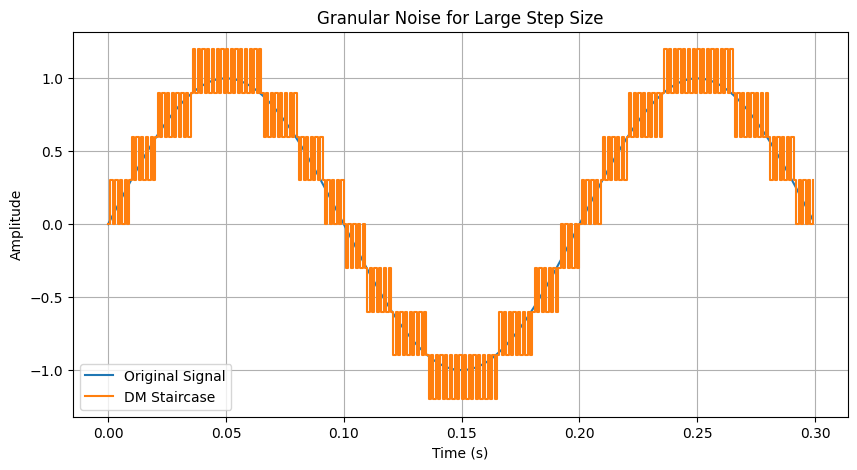

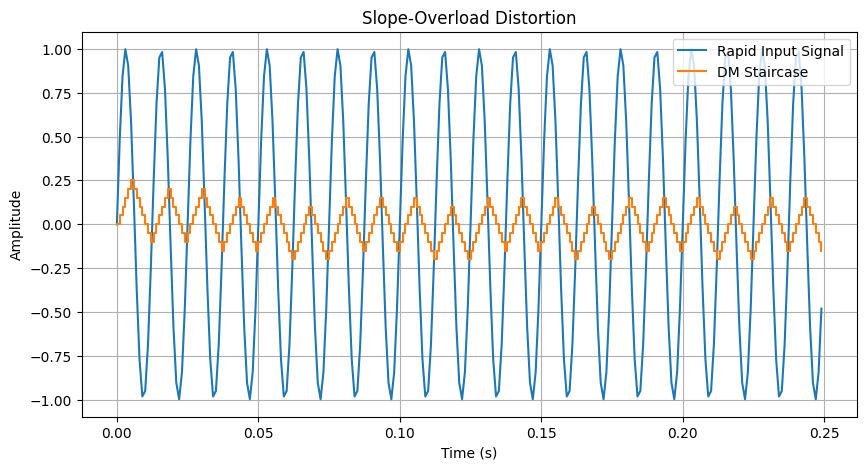

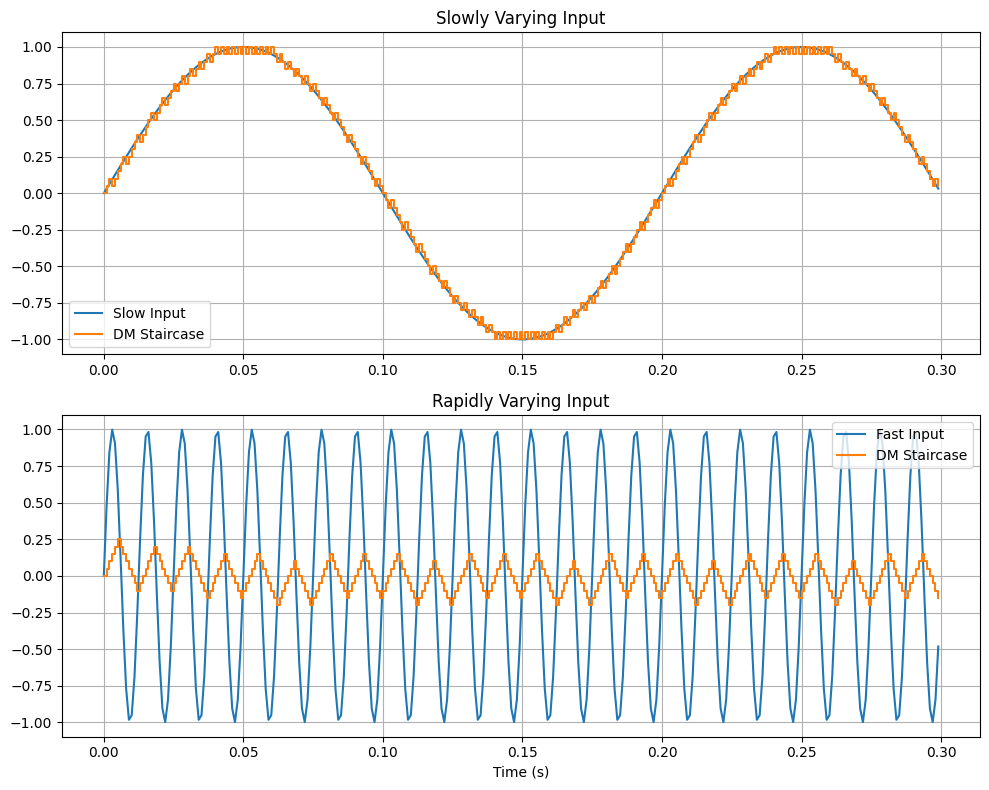

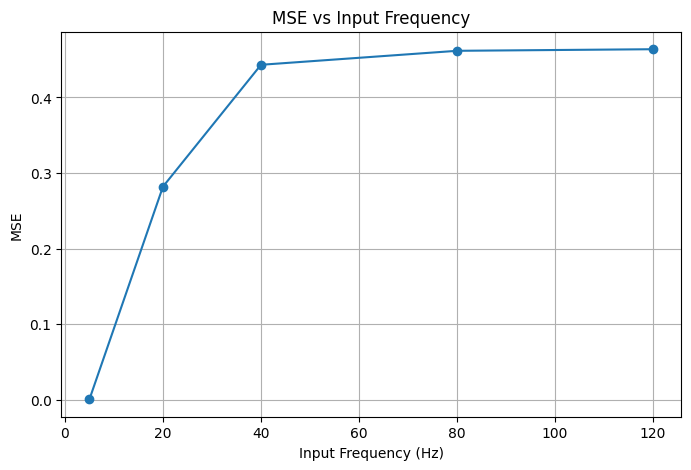


        EXPERIMENT COMPLETED

DPCM:
PCM MSE : 0.0007703270090782397
DPCM MSE: 0.0004924529984825786

Delta Modulation MSE:
Δ = 0.05  --> MSE = 0.000844
Δ = 0.15  --> MSE = 0.007120
Δ = 0.30  --> MSE = 0.030204

Observation:
- Small Δ gives finer staircase resolution.
- Large Δ can produce granular noise.
- Very small Δ with rapidly changing input can cause
  slope-overload distortion.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 5: DPCM AND DELTA MODULATION
# ============================================================

np.random.seed(10)

# ------------------------------------------------------------
# 1. Generate input signal
# ------------------------------------------------------------

fs = 1000                 # Sampling frequency
duration = 1              # seconds
t = np.arange(0, duration, 1/fs)

# Input sinusoidal signal
f = 5                    # Signal frequency
A = 1                    # Amplitude

x = A * np.sin(2 * np.pi * f * t)


# ============================================================
# PART A : DPCM
# ============================================================

# ------------------------------------------------------------
# 2. First-order prediction
# ------------------------------------------------------------

# Predictor:
# x_hat[n] = x[n-1]

x_pred = np.zeros_like(x)
x_pred[0] = 0

for n in range(1, len(x)):
    x_pred[n] = x[n-1]

# Prediction error
prediction_error = x - x_pred


# ------------------------------------------------------------
# 3. DPCM quantization
# ------------------------------------------------------------

dpcm_step = 0.1

# Quantize prediction error
dpcm_error_quantized = (
    np.round(prediction_error / dpcm_step) * dpcm_step
)

# Reconstruct signal
x_dpcm = x_pred + dpcm_error_quantized


# ------------------------------------------------------------
# 4. Ordinary PCM quantization
# ------------------------------------------------------------

pcm_quantized = (
    np.round(x / dpcm_step) * dpcm_step
)

pcm_error = x - pcm_quantized

# DPCM quantization error
dpcm_quantization_error = x - x_dpcm


# ------------------------------------------------------------
# 5. Calculate MSE
# ------------------------------------------------------------

pcm_mse = np.mean((x - pcm_quantized) ** 2)
dpcm_mse = np.mean((x - x_dpcm) ** 2)

print("========== DPCM RESULTS ==========")
print("PCM MSE  :", pcm_mse)
print("DPCM MSE :", dpcm_mse)


# ------------------------------------------------------------
# 6. Original vs Predicted Samples
# ------------------------------------------------------------

N = 100

plt.figure(figsize=(10, 5))

plt.plot(
    t[:N],
    x[:N],
    label="Original Signal"
)

plt.plot(
    t[:N],
    x_pred[:N],
    '--',
    label="Predicted Signal"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original and Predicted Samples")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7. Prediction Error
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    t[:N],
    prediction_error[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("DPCM Prediction Error")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 8. PCM vs DPCM reconstruction
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    t[:N],
    x[:N],
    label="Original"
)

plt.step(
    t[:N],
    pcm_quantized[:N],
    where='mid',
    label="PCM"
)

plt.step(
    t[:N],
    x_dpcm[:N],
    where='mid',
    label="DPCM"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("PCM and DPCM Reconstruction")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART B : DELTA MODULATION
# ============================================================

# ------------------------------------------------------------
# 9. Delta Modulation Function
# ------------------------------------------------------------

def delta_modulation(signal, delta):
    """
    Delta modulation encoder.

    At every sample:
        +delta -> if input > previous staircase value
        -delta -> if input < previous staircase value
    """

    staircase = np.zeros(len(signal))
    dm_bits = np.zeros(len(signal), dtype=int)

    staircase[0] = 0

    for n in range(1, len(signal)):

        if signal[n] >= staircase[n-1]:
            dm_bits[n] = 1
            staircase[n] = staircase[n-1] + delta

        else:
            dm_bits[n] = 0
            staircase[n] = staircase[n-1] - delta

    return dm_bits, staircase


# ------------------------------------------------------------
# 10. Mandatory validation function
# ------------------------------------------------------------

def validate_delta_steps(staircase, delta):

    changes = np.diff(staircase)

    # Ignore first sample because there is no previous value
    valid = np.all(
        np.isclose(
            np.abs(changes[1:]),
            delta
        )
    )

    print("\n========== DELTA VALIDATION ==========")

    if valid:
        print("PASS: Every staircase change is exactly +Δ or -Δ.")
    else:
        print("FAIL: Some staircase changes are not ±Δ.")

    # Show unique step values
    unique_steps = np.unique(np.round(changes[1:], 10))

    print("Unique staircase changes:", unique_steps)

    return valid


# ============================================================
# 11. Delta modulation with different step sizes
# ============================================================

delta_values = [0.05, 0.15, 0.30]

plt.figure(figsize=(12, 8))

for i, delta in enumerate(delta_values):

    bits, staircase = delta_modulation(x, delta)

    plt.subplot(3, 1, i + 1)

    plt.plot(
        t[:300],
        x[:300],
        label="Original Signal"
    )

    plt.step(
        t[:300],
        staircase[:300],
        where='post',
        label=f"DM Staircase (Δ={delta})"
    )

    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()

plt.xlabel("Time (s)")
plt.suptitle("Delta Modulation for Different Step Sizes")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Validate all step sizes
# ------------------------------------------------------------

for delta in delta_values:

    bits, staircase = delta_modulation(x, delta)

    print(f"\nDelta = {delta}")

    validate_delta_steps(
        staircase,
        delta
    )


# ============================================================
# 13. Calculate MSE for different step sizes
# ============================================================

mse_values = []

for delta in delta_values:

    bits, staircase = delta_modulation(x, delta)

    mse = np.mean(
        (x - staircase) ** 2
    )

    mse_values.append(mse)


plt.figure(figsize=(8, 5))

plt.plot(
    delta_values,
    mse_values,
    marker='o'
)

plt.xlabel("Step Size Δ")
plt.ylabel("MSE")
plt.title("MSE vs Step Size")
plt.grid(True)
plt.show()


# ============================================================
# PART C : GRANULAR NOISE
# ============================================================

# Large step size compared with slowly varying signal
delta_granular = 0.30

bits_g, staircase_g = delta_modulation(
    x,
    delta_granular
)

plt.figure(figsize=(10, 5))

plt.plot(
    t[:300],
    x[:300],
    label="Original Signal"
)

plt.step(
    t[:300],
    staircase_g[:300],
    where='post',
    label="DM Staircase"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Granular Noise for Large Step Size")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART D : SLOPE-OVERLOAD DISTORTION
# ============================================================

# ------------------------------------------------------------
# Rapidly varying input
# ------------------------------------------------------------

f_fast = 80

x_fast = A * np.sin(
    2 * np.pi * f_fast * t
)

# Small step size
delta_small = 0.05

bits_fast, staircase_fast = delta_modulation(
    x_fast,
    delta_small
)

plt.figure(figsize=(10, 5))

plt.plot(
    t[:250],
    x_fast[:250],
    label="Rapid Input Signal"
)

plt.step(
    t[:250],
    staircase_fast[:250],
    where='post',
    label="DM Staircase"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Slope-Overload Distortion")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART E : SLOW vs FAST INPUT
# ============================================================

f_slow = 5
f_fast = 80

x_slow = A * np.sin(
    2 * np.pi * f_slow * t
)

x_fast = A * np.sin(
    2 * np.pi * f_fast * t
)

delta = 0.05

_, staircase_slow = delta_modulation(
    x_slow,
    delta
)

_, staircase_fast = delta_modulation(
    x_fast,
    delta
)


plt.figure(figsize=(10, 8))

# Slow input
plt.subplot(2, 1, 1)

plt.plot(
    t[:300],
    x_slow[:300],
    label="Slow Input"
)

plt.step(
    t[:300],
    staircase_slow[:300],
    where='post',
    label="DM Staircase"
)

plt.title("Slowly Varying Input")
plt.grid(True)
plt.legend()


# Fast input
plt.subplot(2, 1, 2)

plt.plot(
    t[:300],
    x_fast[:300],
    label="Fast Input"
)

plt.step(
    t[:300],
    staircase_fast[:300],
    where='post',
    label="DM Staircase"
)

plt.title("Rapidly Varying Input")
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# PART F : Compare MSE for different frequencies
# ============================================================

frequency_values = [5, 20, 40, 80, 120]

frequency_mse = []

for freq in frequency_values:

    signal = A * np.sin(
        2 * np.pi * freq * t
    )

    _, staircase = delta_modulation(
        signal,
        delta_small
    )

    mse = np.mean(
        (signal - staircase) ** 2
    )

    frequency_mse.append(mse)


plt.figure(figsize=(8, 5))

plt.plot(
    frequency_values,
    frequency_mse,
    marker='o'
)

plt.xlabel("Input Frequency (Hz)")
plt.ylabel("MSE")
plt.title("MSE vs Input Frequency")
plt.grid(True)
plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n======================================")
print("        EXPERIMENT COMPLETED")
print("======================================")

print("\nDPCM:")
print("PCM MSE :", pcm_mse)
print("DPCM MSE:", dpcm_mse)

print("\nDelta Modulation MSE:")

for delta, mse in zip(delta_values, mse_values):
    print(f"Δ = {delta:.2f}  --> MSE = {mse:.6f}")

print("\nObservation:")
print("- Small Δ gives finer staircase resolution.")
print("- Large Δ can produce granular noise.")
print("- Very small Δ with rapidly changing input can cause")
print("  slope-overload distortion.")